## Cell 1 - Imports and paths

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

from biochemical_stain_assessment.czi_io import read_czi
from biochemical_stain_assessment.register_overlay import (
    crop_to_abpas_fov,
    resample_to_pixel_size,
    save_ome_tiff,
    save_preview_png,
)
from biochemical_stain_assessment.registration import (
    AffineParams,
    abpas_inv_gray,
    apply_scale_translation,
    enhance_dapi,
    estimate_stain_matrix,
    mutual_crop,
    normalise_abpas,
    register_contour,
    save_affine_params,
    save_stain_matrix,
    segment_organoid,
)

from biochemical_stain_assessment.registration.contour_register import (
    register_contour_from_props,
 )



In [19]:
DATA_DIR = Path("../data/data_1_5/JH-311")
OUT_DIR = Path("../data/registered_output/contour_demo")
OUT_DIR.mkdir(parents=True, exist_ok=True)
DISPLAY_STEP = 4

# ABPAS_CZI = DATA_DIR / "AbPAS" / "ITG_Rusha_JH-311_Organoid_AbPAS_HMGU1-1.czi"
# DAPI_CZI = DATA_DIR / "DAPI" / "ITG_Rusha_JH-311_Organoid_Hoechst33342_HMGU1-1.czi"

ABPAS_CZI = DATA_DIR / "AbPAS" / "ITG_Rusha_JH-311_Organoid_AbPAS_ACAN4_F2.czi"
DAPI_CZI = DATA_DIR / "DAPI" / "ITG_Rusha_JH-311_Organoid_Hoechst33342_ACAN4_F2.czi"

def add_props_ellipse(ax, props, color, label, scale=1.0, tx=0.0, ty=0.0):
    center_row = scale * props.centroid_row + ty
    center_col = scale * props.centroid_col + tx
    angle = 90.0 - np.degrees(props.orientation)
    ellipse = Ellipse(
        (center_col, center_row),
        width=scale * props.axis_major,
        height=scale * props.axis_minor,
        angle=angle,
        fill=False,
        edgecolor=color,
        linewidth=2,
        label=label,
    )
    ax.add_patch(ellipse)
    ax.scatter([center_col], [center_row], c=color, s=40, marker="+")
    return ellipse

## Cell 2 - Load images and show raw

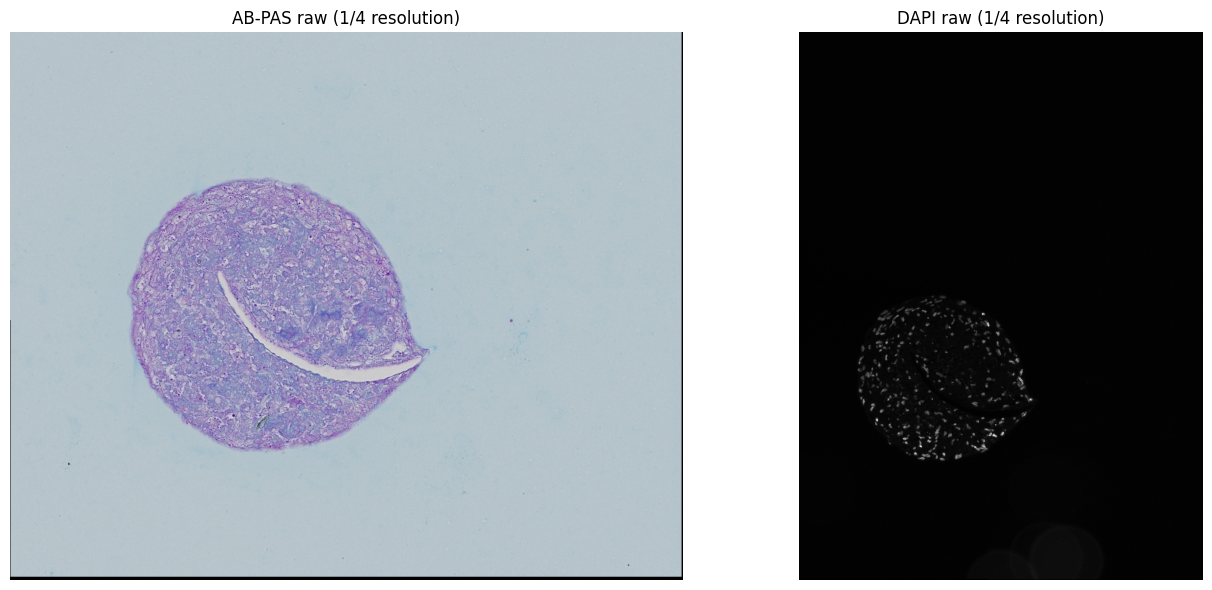

AB-PAS: shape=(4688, 5760, 3), pixel size=0.1726 um/px
DAPI:   shape=(3892, 2864), pixel size=0.3442 um/px


In [20]:
abpas, px_abpas, _, cx_a, cy_a, _ = read_czi(ABPAS_CZI)
dapi, px_dapi, _, cx_d, cy_d, _ = read_czi(DAPI_CZI)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(abpas[::4, ::4])
axes[0].set_title("AB-PAS raw (1/4 resolution)")
axes[0].axis("off")
axes[1].imshow(dapi[::4, ::4], cmap="gray")
axes[1].set_title("DAPI raw (1/4 resolution)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"AB-PAS: shape={abpas.shape}, pixel size={px_abpas:.4f} um/px")
print(f"DAPI:   shape={dapi.shape}, pixel size={px_dapi:.4f} um/px")

## Cell 3 - Resample and coarse crop

Resampled DAPI shape: (7768, 8420)
After coarse crop: abpas=(6909, 5765, 3), dapi_crop=(6909, 5765)
DAPI crop offset in resampled image: row=189, col=0


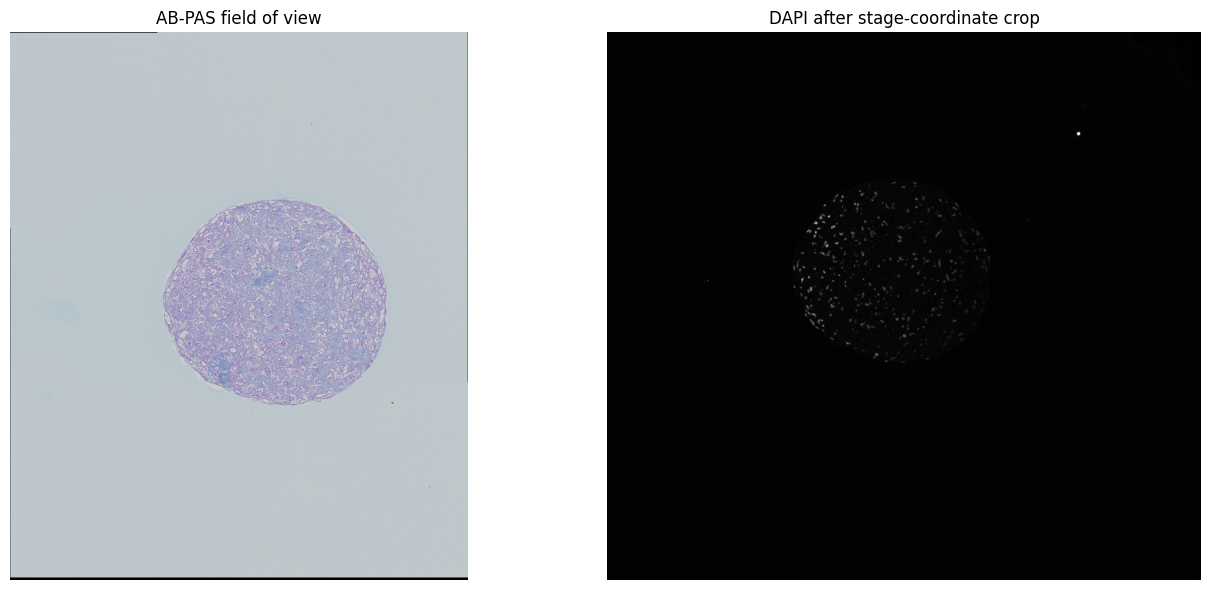

In [ ]:
dapi_rs = resample_to_pixel_size(dapi, px_dapi, px_abpas)
dapi_crop, r0, c0 = crop_to_abpas_fov(
    dapi_rs,
    abpas.shape[0],
    abpas.shape[1],
    cx_a,
    cy_a,
    cx_d,
    cy_d,
    px_abpas,
)

if dapi_crop.shape[:2] != abpas.shape[:2]:
    pad_r = abpas.shape[0] - dapi_crop.shape[0]
    pad_c = abpas.shape[1] - dapi_crop.shape[1]
    dapi_crop = np.pad(
        dapi_crop,
        [(pad_r // 2, pad_r - pad_r // 2), (pad_c // 2, pad_c - pad_c // 2)],
        mode="constant",
    )

print(f"Resampled DAPI shape: {dapi_rs.shape}")
print(f"After coarse crop: abpas={abpas.shape}, dapi_crop={dapi_crop.shape}")
print(f"DAPI crop offset in resampled image: row={r0}, col={c0}")
print("Crop does not work properly and likely needs manual adjustment. Check the displayed images to verify.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(abpas[::4, ::4])
axes[0].set_title("AB-PAS field of view")
axes[0].axis("off")
axes[1].imshow(dapi_rs[::4, ::4], cmap="gray")
axes[1].set_title("DAPI after stage-coordinate crop")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Cell 4 - Preprocess AB-PAS and DAPI

Stain matrix:
 [[0.67146345 0.68755643 0.27641091]
 [0.67539169 0.68335693 0.27725327]]


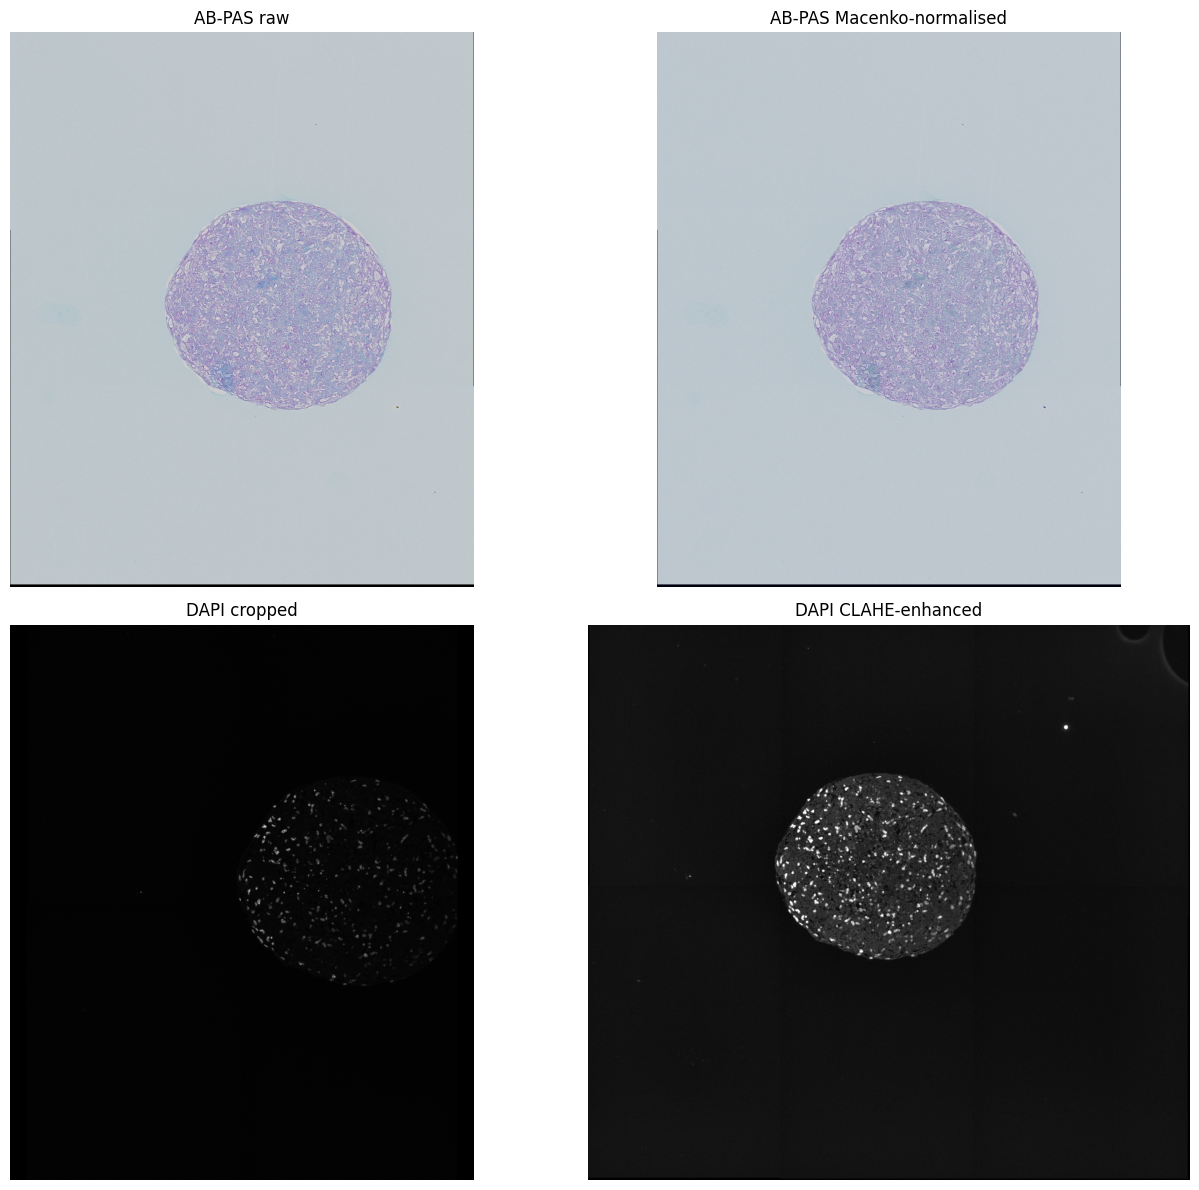

In [13]:
stain_mtx = estimate_stain_matrix(abpas)
save_stain_matrix(
    stain_mtx,
    OUT_DIR / "stain_matrix_HMGU1-1.json",
    sample_id="HMGU1-1",
    estimated_from=str(ABPAS_CZI),
)

abpas_norm = normalise_abpas(abpas, stain_matrix_target=stain_mtx)
dapi_enhanced = enhance_dapi(dapi_rs, clahe_clip_limit=0.01, tophat=False)

print("Stain matrix:\n", stain_mtx)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes[0, 0].imshow(abpas[::4, ::4])
axes[0, 0].set_title("AB-PAS raw")
axes[0, 0].axis("off")
axes[0, 1].imshow(abpas_norm[::4, ::4])
axes[0, 1].set_title("AB-PAS Macenko-normalised")
axes[0, 1].axis("off")
axes[1, 0].imshow(dapi_crop[::4, ::4], cmap="gray")
axes[1, 0].set_title("DAPI cropped")
axes[1, 0].axis("off")
axes[1, 1].imshow(dapi_enhanced[::4, ::4], cmap="gray")
axes[1, 1].set_title("DAPI CLAHE-enhanced")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

## Cell 5 - Segment organoid contours

AB-PAS organoid props: OrganoidProps(centroid_row=3413.820118554174, centroid_col=3363.126353790614, axis_major=2820.5261621232407, axis_minor=2596.148731455073, orientation=1.3794953738288926, area_px=5743872, mean_axis=2708.337446789157)
DAPI organoid props:   OrganoidProps(centroid_row=3391.050533022638, centroid_col=4040.65849402812, axis_major=2802.3210775134953, axis_minor=2587.6161723805476, orientation=1.419767147871115, area_px=5685312, mean_axis=2694.9686249470215)


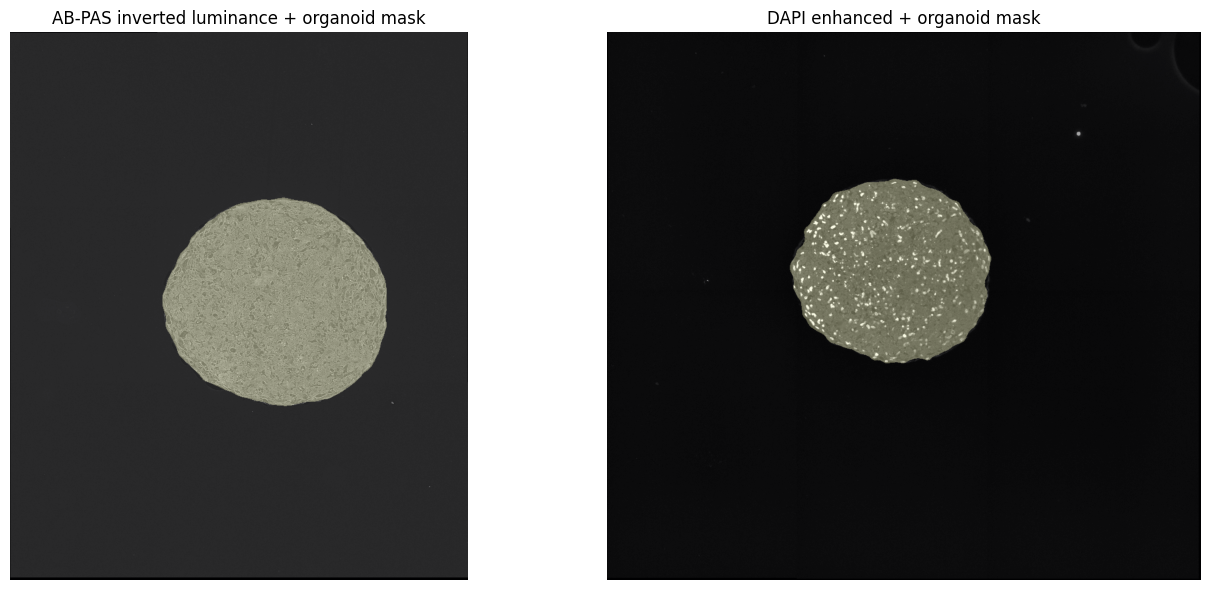

In [14]:
ref_gray = abpas_inv_gray(abpas_norm)
mask_ref, props_ref = segment_organoid(ref_gray)
mask_mov, props_mov = segment_organoid(dapi_enhanced)

print("AB-PAS organoid props:", props_ref)
print("DAPI organoid props:  ", props_mov)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ref_gray[::4, ::4], cmap="gray")
axes[0].imshow(mask_ref[::4, ::4], cmap="magma", alpha=0.35)
axes[0].set_title("AB-PAS inverted luminance + organoid mask")
axes[0].axis("off")
axes[1].imshow(dapi_enhanced[::4, ::4], cmap="gray")
axes[1].imshow(mask_mov[::4, ::4], cmap="magma", alpha=0.35)
axes[1].set_title("DAPI enhanced + organoid mask")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Cell 6 - Fit contour-based affine transform

AffineParams: AffineParams(scale=1.004960659548457, tx=-697.5764713779608, ty=5.947738325597129, n_inliers=1, method='contour', rmse=0.0)


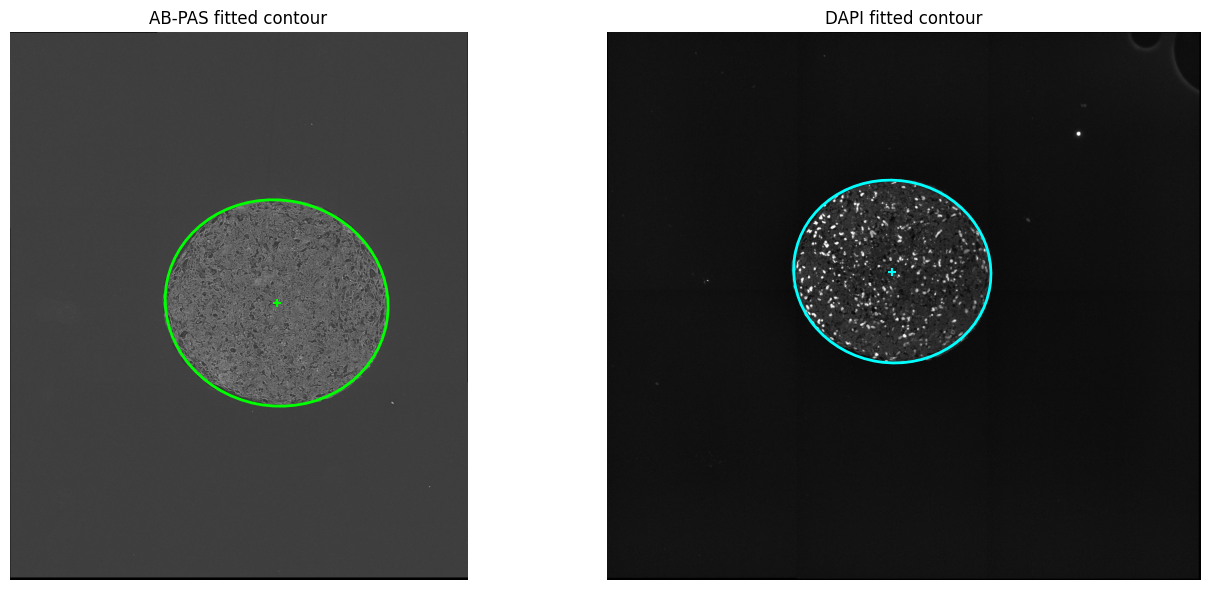

In [15]:
params, props_ref_fit, props_mov_fit = register_contour_from_props(
    props_ref,
    props_mov,
    px_um=px_abpas,
    max_shift_um=None, # 100.00
)
if params.method == "contour_failed":
    print("Contour registration failed; using stage-coordinate fallback for display/save.")
    params = AffineParams(1.0, 0.0, 0.0, 0, "stage_coords", 0.0)

print("AffineParams:", params)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ref_gray[::DISPLAY_STEP, ::DISPLAY_STEP], cmap="gray")
add_props_ellipse(axes[0], props_ref_fit, "lime", "AB-PAS contour", scale=1.0 / DISPLAY_STEP)
axes[0].set_title("AB-PAS fitted contour")
axes[0].axis("off")
axes[1].imshow(dapi_enhanced[::DISPLAY_STEP, ::DISPLAY_STEP], cmap="gray")
add_props_ellipse(axes[1], props_mov_fit, "cyan", "DAPI contour", scale=1.0 / DISPLAY_STEP)
axes[1].set_title("DAPI fitted contour")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Cell 7 - Warp DAPI and inspect overlay

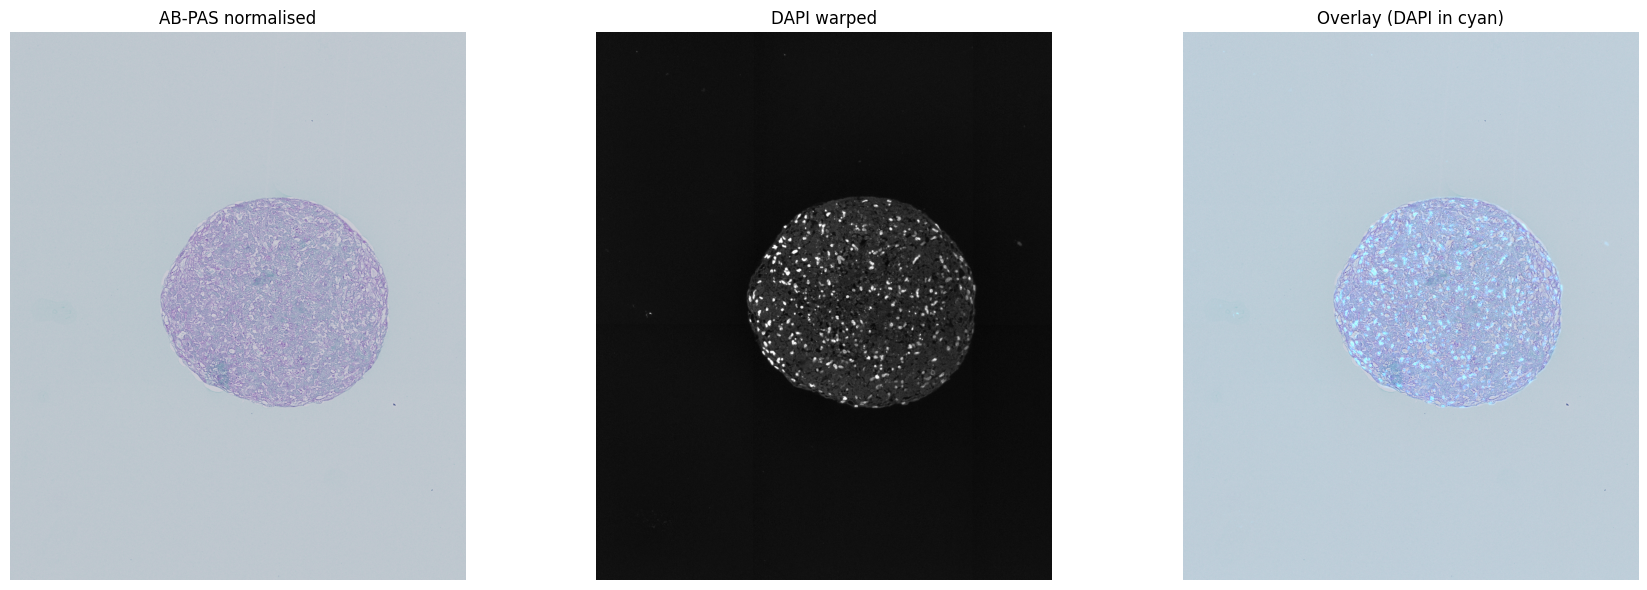

In [16]:
dapi_warped = apply_scale_translation(
    dapi_enhanced,
    params.scale,
    params.tx,
    params.ty,
    output_shape=abpas_norm.shape[:2],
)
abpas_final, dapi_final = mutual_crop(abpas_norm, dapi_warped, margin=64)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(abpas_final[::4, ::4])
axes[0].set_title("AB-PAS normalised")
axes[0].axis("off")
axes[1].imshow(dapi_final[::4, ::4], cmap="gray")
axes[1].set_title("DAPI warped")
axes[1].axis("off")
overlay = abpas_final[::4, ::4].astype(np.float32) / 255.0
dapi_small = dapi_final[::4, ::4]
overlay[:, :, 1] = np.clip(overlay[:, :, 1] + 0.35 * dapi_small, 0, 1)
overlay[:, :, 2] = np.clip(overlay[:, :, 2] + 0.55 * dapi_small, 0, 1)
axes[2].imshow(overlay)
axes[2].set_title("Overlay (DAPI in cyan)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Cell 8 - Post-warp contour QC

Post-warp centroid residual: 0.23 px (0.04 um)


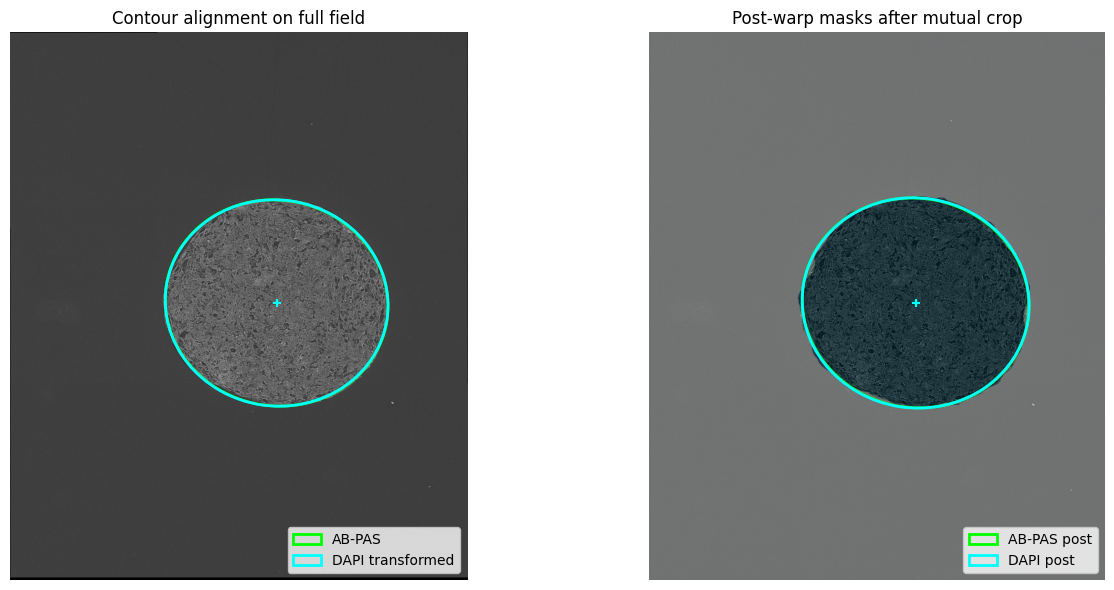

In [17]:
ref_final_gray = abpas_inv_gray(abpas_final)
mask_ref_post, props_ref_post = segment_organoid(ref_final_gray)
mask_mov_post, props_mov_post = segment_organoid(dapi_final)
residual_px = np.hypot(
    props_ref_post.centroid_row - props_mov_post.centroid_row,
    props_ref_post.centroid_col - props_mov_post.centroid_col,
)
print(f"Post-warp centroid residual: {residual_px:.2f} px ({residual_px * px_abpas:.2f} um)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ref_gray[::DISPLAY_STEP, ::DISPLAY_STEP], cmap="gray")
add_props_ellipse(axes[0], props_ref_fit, "lime", "AB-PAS", scale=1.0 / DISPLAY_STEP)
add_props_ellipse(
    axes[0],
    props_mov_fit,
    "cyan",
    "DAPI transformed",
    scale=params.scale / DISPLAY_STEP,
    tx=params.tx / DISPLAY_STEP,
    ty=params.ty / DISPLAY_STEP,
)
axes[0].set_title("Contour alignment on full field")
axes[0].axis("off")
axes[0].legend(loc="lower right")

axes[1].imshow(ref_final_gray[::DISPLAY_STEP, ::DISPLAY_STEP], cmap="gray")
axes[1].imshow(mask_ref_post[::DISPLAY_STEP, ::DISPLAY_STEP], cmap="Greens", alpha=0.25)
axes[1].imshow(mask_mov_post[::DISPLAY_STEP, ::DISPLAY_STEP], cmap="Blues", alpha=0.25)
add_props_ellipse(axes[1], props_ref_post, "lime", "AB-PAS post", scale=1.0 / DISPLAY_STEP)
add_props_ellipse(axes[1], props_mov_post, "cyan", "DAPI post", scale=1.0 / DISPLAY_STEP)
axes[1].set_title("Post-warp masks after mutual crop")
axes[1].axis("off")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

## Cell 9 - Save OME-TIFF, preview, and params

In [18]:
img_stem = ABPAS_CZI.stem.replace("AbPAS", "Registered").replace("AbPAS_", "")

In [11]:
tiff_path = OUT_DIR / f"{img_stem}.ome.tif"
png_path = OUT_DIR / f"{img_stem}_preview.png"
params_path = OUT_DIR / f"{img_stem}_affine_params.json"

dapi_final_u16 = (dapi_final * 65535).astype(np.uint16)
save_ome_tiff(str(tiff_path), abpas_final, dapi_final_u16, px_abpas, img_stem)
save_preview_png(str(png_path), abpas_final, dapi_final_u16)
save_affine_params(params, params_path, img_stem, str(ABPAS_CZI), str(DAPI_CZI))

print("Saved:")
for path in [tiff_path, png_path, params_path, OUT_DIR / f"stain_matrix_{img_stem}.json"]:
    print(f"  {path}")

Saved:
  ../data/registered_output/contour_demo/ITG_Rusha_JH-311_Organoid_Registered_ACAN4_F1.ome.tif
  ../data/registered_output/contour_demo/ITG_Rusha_JH-311_Organoid_Registered_ACAN4_F1_preview.png
  ../data/registered_output/contour_demo/ITG_Rusha_JH-311_Organoid_Registered_ACAN4_F1_affine_params.json
  ../data/registered_output/contour_demo/stain_matrix_ITG_Rusha_JH-311_Organoid_Registered_ACAN4_F1.json
